In [ ]:
# train_fusion_classification_f1.py
import os
import random
import csv
import time

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score
)

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from tqdm import tqdm

# -----------------------------
# CONFIG
# -----------------------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 100
LR = 2e-4
WEIGHT_DECAY = 1e-4
EFF_WEIGHT = 0.75
PATIENCE = 10
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = r"D:\LIMUC"
CHECKPOINT_PATH = "best_fusion_f1.pth"
PLOTS_DIR = "training_plots_f1"

os.makedirs(PLOTS_DIR, exist_ok=True)

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# Simple ImageFolder Dataset (NO MASK)
# -----------------------------
class SimpleImageFolder(Dataset):
    def __init__(self, root):
        self.samples = []
        self.classes = sorted(
            [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
        )
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for c in self.classes:
            cls_dir = os.path.join(root, c)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[c])
                    )

        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label

# -----------------------------
# Fusion Model (MULTICLASS)
# -----------------------------
class ResEffFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.eff = timm.create_model(
            "efficientnet_b4", pretrained=True, features_only=True
        )
        self.res = timm.create_model(
            "resnet50", pretrained=True, features_only=True
        )

        eff_dim = self.eff.feature_info[-1]['num_chs']
        res_dim = self.res.feature_info[-1]['num_chs']

        self.eff_proj = nn.Conv2d(eff_dim, 1024, 1)
        self.res_proj = nn.Conv2d(res_dim, 1024, 1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)

        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        eff_feat = self.eff(x)[-1]
        res_feat = self.res(x)[-1]

        if eff_feat.shape[2:] != res_feat.shape[2:]:
            res_feat = nn.functional.interpolate(
                res_feat, size=eff_feat.shape[2:],
                mode="bilinear", align_corners=False
            )

        eff_f = self.eff_proj(eff_feat)
        res_f = self.res_proj(res_feat)

        fused = 0.75 * eff_f + 0.25 * res_f
        fused = self.relu(self.bn(fused))

        pooled = self.pool(fused).flatten(1)
        pooled = self.dropout(pooled)

        return self.classifier(pooled)

# -----------------------------
# EarlyStopping (F1-based)
# -----------------------------
class EarlyStopping:
    def __init__(self, patience):
        self.best = -1
        self.counter = 0
        self.patience = patience

    def step(self, metric):
        if metric > self.best:
            self.best = metric
            self.counter = 0
            return False, True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True, False
            return False, False

# -----------------------------
# Training Pipeline
# -----------------------------
def train():

    train_ds = SimpleImageFolder(os.path.join(DATA_ROOT, "train"))
    val_ds   = SimpleImageFolder(os.path.join(DATA_ROOT, "val"))
    test_ds  = SimpleImageFolder(os.path.join(DATA_ROOT, "test"))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

    NUM_CLASSES = len(train_ds.classes)
    print("Classes:", train_ds.classes)

    model = ResEffFusion(NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR,
                            weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    earlystop = EarlyStopping(PATIENCE)

    for epoch in range(EPOCHS):

        # ---------------- TRAIN ----------------
        model.train()
        running_loss = 0

        for imgs, labels in tqdm(train_loader,
                                 desc=f"Epoch {epoch+1}/{EPOCHS}"):

            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        # ---------------- VALIDATION ----------------
        model.eval()
        y_true = []
        y_pred = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE)
                outputs = model(imgs)
                preds = torch.argmax(outputs, dim=1)

                y_true.extend(labels.numpy())
                y_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

        print(f"Val → Acc: {acc:.4f} | F1: {macro_f1:.4f} | QWK: {qwk:.4f}")

        stop, is_best = earlystop.step(macro_f1)

        if is_best:
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print("Saved best model (F1 improved)")

        if stop:
            print("Early stopping.")
            break

    # ---------------- TEST ----------------
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print("\n===== TEST RESULTS =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1 (PRIMARY): {macro_f1:.4f}")
    print(f"QWK (secondary): {qwk:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=train_ds.classes))

if __name__ == "__main__":
    train()


========== MAIN METRICS ==========
Accuracy: 0.7831858407079646
QWK: 0.8591663613711421

Classification Report:

              precision    recall  f1-score   support

      Mayo 0       0.88      0.88      0.88       611
      Mayo 1       0.67      0.65      0.66       306
      Mayo 2       0.60      0.63      0.62       126
      Mayo 3       0.79      0.76      0.77        87

    accuracy                           0.78      1130
   macro avg       0.73      0.73      0.73      1130
weighted avg       0.78      0.78      0.78      1130



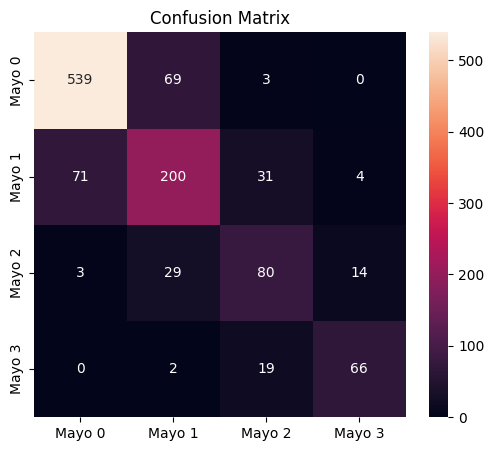

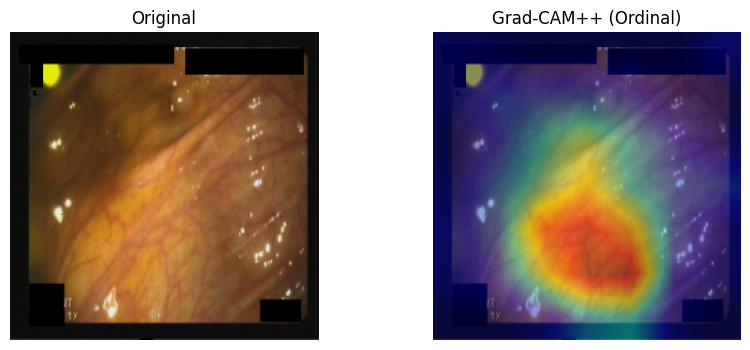

In [2]:
# ============================================================
# FULL ORDINAL EVALUATION + GRADCAM++ (MASK-AWARE)
# ============================================================

import os
import cv2
import torch
import timm
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD


# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 16
CLEAN_ROOT = r"D:\severity_cleaned_mask"     # must contain train/, val/, test/ subfolders with masks saved as <base>_mask.png
CHECKPOINT_PATH = "best_reseff_fusion_masked_ordinal.pth"


# ============================================================
# MASK-AWARE DATASET
# ============================================================

class MaskedImageFolder(Dataset):

    def __init__(self, root):
        self.samples = []
        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp')) and not fname.endswith("_mask.png"):
                    img_path = os.path.join(cls_dir, fname)
                    base = os.path.splitext(fname)[0]
                    mask_path = os.path.join(cls_dir, f"{base}_mask.png")
                    if not os.path.exists(mask_path):
                        mask_path = None
                    self.samples.append((img_path, mask_path, self.class_to_idx[cls]))

        self.mean_tensor = torch.tensor(IMAGENET_DEFAULT_MEAN).view(3,1,1).float()

        self.transform = transforms.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self):
        return len(self.samples)

    def _load_mask(self, path):
        if path is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        return (m > 127).astype(np.uint8)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        pil = Image.open(img_path).convert("RGB")
        pil = self.transform(pil)

        img_tensor = transforms.ToTensor()(pil)

        mask_np = self._load_mask(mask_path)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()

        img_tensor = img_tensor * mask_tensor + (1 - mask_tensor) * self.mean_tensor
        img_tensor = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)(img_tensor)

        return img_tensor, label


# ============================================================
# ORDINAL MODEL (K-1 outputs)
# ============================================================

class ResEffFusion(nn.Module):

    def __init__(self, num_classes, eff_weight=0.7):
        super().__init__()

        self.eff_weight = eff_weight
        self.res_weight = 1 - eff_weight
        self.num_classes = num_classes

        self.eff = timm.create_model("efficientnet_b4", pretrained=False, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']

        self.res = timm.create_model("resnet50", pretrained=False, features_only=True)
        res_dim = self.res.feature_info[-1]['num_chs']

        self.eff_proj = nn.Conv2d(eff_dim, 1024, kernel_size=1)
        self.res_proj = nn.Conv2d(res_dim, 1024, kernel_size=1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU(inplace=False)

        self.pool = nn.AdaptiveAvgPool2d(1)

        # CORAL → K-1 logits
        self.classifier = nn.Linear(1024, num_classes - 1)

    def forward(self, x):
        eff_feat = self.eff(x)[-1]
        res_feat = self.res(x)[-1]

        if eff_feat.shape[2:] != res_feat.shape[2:]:
            res_feat = nn.functional.interpolate(res_feat, size=eff_feat.shape[2:], mode="bilinear", align_corners=False)

        eff_feat = self.eff_proj(eff_feat)
        res_feat = self.res_proj(res_feat)

        fused = self.eff_weight * eff_feat + self.res_weight * res_feat
        fused = self.relu(self.bn(fused))

        pooled = self.pool(fused).flatten(1)
        return self.classifier(pooled)


# ============================================================
# CORAL → class probabilities
# ============================================================

def coral_logits_to_probs(logits):
    sig = torch.sigmoid(logits)
    K_1 = logits.size(1)
    K = K_1 + 1

    probs = []
    probs.append((1 - sig[:, 0]).unsqueeze(1))

    for r in range(1, K-1):
        probs.append((sig[:, r-1] - sig[:, r]).unsqueeze(1))

    probs.append(sig[:, K-2].unsqueeze(1))

    probs = torch.cat(probs, dim=1)
    probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-12)
    return probs


# ============================================================
# GRADCAM++ (ORDINAL SAFE)
# ============================================================

class GradCAMpp:

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()

        logits = self.model(input_tensor)

        probs = coral_logits_to_probs(logits)
        score = probs[:, target_class].sum()

        score.backward(retain_graph=True)

        activations = self.activations
        gradients = self.gradients

        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3
        sum_activations = torch.sum(activations, dim=(2,3), keepdim=True)

        alpha = grads_power_2 / (2 * grads_power_2 + sum_activations * grads_power_3 + 1e-8)
        positive_grad = torch.relu(gradients)
        weights = torch.sum(alpha * positive_grad, dim=(2,3))

        cam = torch.sum(weights.unsqueeze(-1).unsqueeze(-1) * activations, dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cv2.resize(cam, (IMG_SIZE, IMG_SIZE))


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    test_root = os.path.join(CLEAN_ROOT, "test") if os.path.exists(os.path.join(CLEAN_ROOT, "test")) else CLEAN_ROOT

    dataset = MaskedImageFolder(test_root)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    CLASS_NAMES = dataset.classes
    NUM_CLASSES = len(CLASS_NAMES)

    model = ResEffFusion(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()

    # ========================================================
    # EVALUATION
    # ========================================================

    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            probs = coral_logits_to_probs(logits)
            preds = probs.argmax(1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print("\n========== MAIN METRICS ==========")
    print("Accuracy:", acc)
    print("QWK:", qwk)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title("Confusion Matrix")
    plt.show()

    # ========================================================
    # GRADCAM++ ON FIRST IMAGE
    # ========================================================

    img_tensor, label = dataset[0]
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    logits = model(input_tensor)
    probs = coral_logits_to_probs(logits)
    pred = probs.argmax(1).item()

    campp = GradCAMpp(model, model.bn)
    cam = campp.generate(input_tensor, pred)

    img_path = dataset.samples[0][0]
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM++ (Ordinal)")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()


Prediction (Ordinal CORAL):
Mayo 0: 0.0249
Mayo 1: 0.0110
Mayo 2: 0.1935
Mayo 3: 0.7706

Predicted Class: Mayo 3


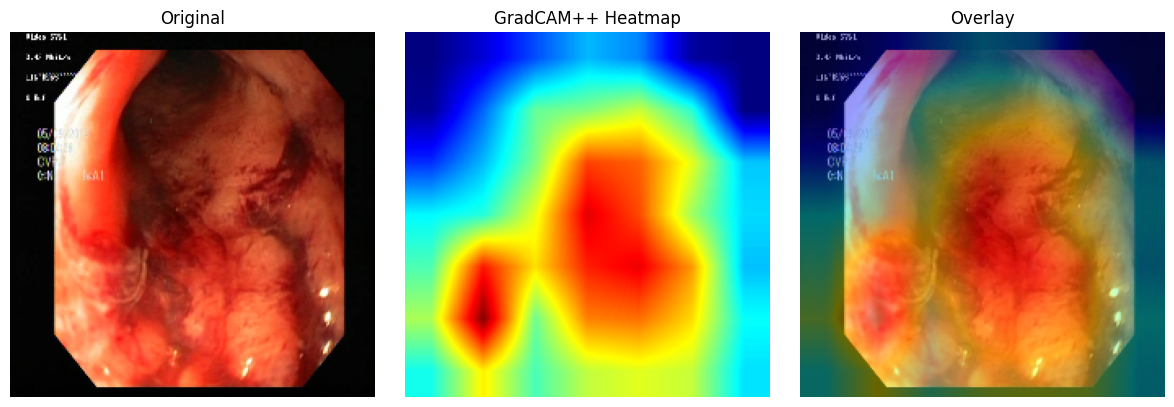

In [3]:
import os
import cv2
import torch
import timm
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
CHECKPOINT_PATH = "best_reseff_fusion_masked_ordinal.pth"

# ORDINAL CLASSES
CLASS_NAMES = ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']

IMAGE_PATH = r"D:\Project\archive\train\1_ulcerative_colitis\584f1fa0-9bb9-49d3-b412-c42819d0a200_00001917.jpg"


# ============================================================
# ORDINAL MODEL (K-1 outputs)
# ============================================================

class ResEffFusion(nn.Module):
    def __init__(self, num_classes, eff_weight=0.75):
        super().__init__()

        self.num_classes = num_classes
        self.eff_weight = eff_weight
        self.res_weight = 1 - eff_weight

        self.eff = timm.create_model("efficientnet_b4", pretrained=False, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']

        self.res = timm.create_model("resnet50", pretrained=False, features_only=True)
        res_dim = self.res.feature_info[-1]['num_chs']

        self.eff_proj = nn.Conv2d(eff_dim, 1024, 1)
        self.res_proj = nn.Conv2d(res_dim, 1024, 1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU(inplace=False)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # CORAL: output K-1 logits
        self.classifier = nn.Linear(1024, num_classes - 1)

    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]

        if eff.shape[2:] != res.shape[2:]:
            res = nn.functional.interpolate(res, size=eff.shape[2:], mode="bilinear", align_corners=False)

        eff = self.eff_proj(eff)
        res = self.res_proj(res)

        fused = self.eff_weight * eff + self.res_weight * res
        fused = self.relu(self.bn(fused))

        pooled = self.pool(fused).flatten(1)
        return self.classifier(pooled)


# ============================================================
# CORAL LOGITS → CLASS PROBABILITIES
# ============================================================

def coral_logits_to_probs(logits):
    sig = torch.sigmoid(logits)  # (1, K-1)

    K_1 = logits.size(1)
    K = K_1 + 1

    probs = []
    probs.append((1 - sig[:, 0]).unsqueeze(1))

    for r in range(1, K-1):
        probs.append((sig[:, r-1] - sig[:, r]).unsqueeze(1))

    probs.append(sig[:, K-2].unsqueeze(1))

    probs = torch.cat(probs, dim=1)
    probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-12)
    return probs


# ============================================================
# GRADCAM++ (ORDINAL SAFE)
# ============================================================

class GradCAMpp:

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()

        logits = self.model(input_tensor)
        probs = coral_logits_to_probs(logits)

        score = probs[:, target_class].sum()
        score.backward(retain_graph=True)

        activations = self.activations
        gradients = self.gradients

        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3
        sum_activations = torch.sum(activations, dim=(2,3), keepdim=True)

        alpha = grads_power_2 / (2 * grads_power_2 + sum_activations * grads_power_3 + 1e-8)
        positive_grad = torch.relu(gradients)
        weights = torch.sum(alpha * positive_grad, dim=(2,3))

        cam = torch.sum(weights.unsqueeze(-1).unsqueeze(-1) * activations, dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cv2.resize(cam, (IMG_SIZE, IMG_SIZE))


# ============================================================
# LOAD MODEL
# ============================================================

model = ResEffFusion(len(CLASS_NAMES)).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()


# ============================================================
# LOAD IMAGE
# ============================================================

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
])

input_tensor = transform(Image.fromarray(img_resized)).unsqueeze(0).to(DEVICE)


# ============================================================
# PREDICTION (ORDINAL)
# ============================================================

with torch.no_grad():
    logits = model(input_tensor)
    probs = coral_logits_to_probs(logits).cpu().numpy().squeeze()
    pred_class = np.argmax(probs)

print("\nPrediction (Ordinal CORAL):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls}: {probs[i]:.4f}")

print("\nPredicted Class:", CLASS_NAMES[pred_class])


# ============================================================
# GRADCAM++
# ============================================================

campp = GradCAMpp(model, model.bn)
cam = campp.generate(input_tensor, pred_class)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_resized, 0.6, heatmap, 0.4, 0)


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_resized)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("GradCAM++ Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()